<a href="https://colab.research.google.com/github/jmfernandez0/cursoCDIA/blob/main/Trabajo_Sadosky.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Objetivos y alcances

○ Definir el objetivo general del análisis.
El objetivo es desarrollar un modelo que prediga el precio solicitado de venta de un inmueble en el Gran Resistencia en base a sus atributos físicos y de localización.

○ Describir las variables presentes en el conjunto de datos.
El conjunto de datos es el conjuntos de listings de inmuebles en venta en Argenprop, Zonaprop y Remax para el Gran Resistencia desde Feb/2025 en adelante.

Se incluyen todos los atributos de la publicación (Tí­tulo,	Tipo de propiedad, DirecciÃ³n,	Precio,	Expensas,	Servicios,	Ambientes,	Instalaciones edificio,	Instalaciones departamento,	Sup. cubierta,	Dormitorios,	Antiguedad,	Baños,	Estado,	DisposiciÃ³n,	Cocheras,	Apto profesional,	Permite mascota,	OrientaciÃ³n,	Descripcion), Fecha y Plataforma de publicación.


In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
import re
import requests
import missingno as msno # instalar e importar missingno


In [28]:
## Ingesta de datos

# URL del archivo
url = 'https://storage.googleapis.com/inmobilario/detalles_propiedades.csv'

# Leer directamente el archivo Excel desde la URL
inmob_df = pd.read_csv(url)

# Verificar las primeras filas del DataFrame
print(inmob_df.head())

inmob_df.shape


   Id_departamento                                     Título  \
0        3745589.0  Alquiler en Colonia Baranda, San Fernando   
1       17368864.0        Venta en Barranqueras, San Fernando   
2       16603591.0               Venta en Centro, Resistencia   
3        4048641.0     Venta en Colonia Baranda, San Fernando   
4       16008477.0     Venta en Colonia Tacuari, San Fernando   

  Tipo de propiedad Tipo de transaccion                       Dirección  \
0             Campo            Alquiler          Ruta 11 Km (chaco) 900   
1             Campo               Venta  Campo 1444 has. Basail, Chaco.   
2             Campo               Venta        7.4 hectáreas zona norte   
3             Campo               Venta          Ruta 11 900, Piso 3500   
4             Campo               Venta                   No disponible   

             Precio       Expensas        Latitud            Longitud  \
0  Consultar precio  No disponible      -27,52847           -59,16162   
1           

(4588, 31)

In [29]:
## ETL - Limpieza de datos


# 1) Eliminar filas vacías en el campo Id_departamento
inmob_df = inmob_df.dropna(subset=['Id_departamento']).copy()

# 2) Crear columna "Moneda" a continuación de Precio
# Primero identificamos la moneda
moneda_serie = pd.Series('', index=inmob_df.index)
moneda_serie.loc[inmob_df['Precio'].str.contains('ARS', na=False)] = 'ARS'
moneda_serie.loc[inmob_df['Precio'].str.contains('USD', na=False)] = 'USD'

# 3) Limpiar campo Precio
inmob_df['Precio'] = inmob_df['Precio'].astype(str).apply(lambda x: re.sub(r'[^\d]', '', x))

inmob_df.shape


# 4) Convertir Precio a float
inmob_df['Precio'] = pd.to_numeric(inmob_df['Precio'], errors='coerce')

# Insertamos la columna "Moneda" después de "Precio"
precio_idx = inmob_df.columns.get_loc('Precio')
inmob_df.insert(precio_idx + 1, 'Moneda', moneda_serie)

# Nueva instrucción: Convertir Id_departamento a integer
inmob_df['Id_departamento'] = pd.to_numeric(inmob_df['Id_departamento'], errors='coerce').astype('Int64')

# 5) Crear Id_externo concatenando el primer caracter de "sitio" y el valor de Id_departamento
id_externo = inmob_df['sitio'].astype(str).str[0] + inmob_df['Id_departamento'].astype(str)

# Insertar Id_externo como primera columna
inmob_df.insert(0, 'Id_externo', id_externo)

inmob_df.shape

# 6) Conservar solo la última fila con Id_externo duplicado
# Ordenamos primero el DataFrame para asegurar que "último" tenga un significado consistente
inmob_df = inmob_df.sort_index()  # Esto asegura que "último" se refiera al orden original
# Luego conservamos la última aparición de cada Id_externo
inmob_df = inmob_df.drop_duplicates(subset=['Id_externo'], keep='last')


# 7) Conservar solo filas con valor "Venta" en columna "Tipo de transaccion"
inmob_df = inmob_df[inmob_df['Tipo de transaccion'] == 'Venta']
inmob_df.shape

# 8) Eliminar columnas posteriores a "Estado del dato"
if 'Estado del dato' in inmob_df.columns:
    idx = inmob_df.columns.get_loc('Estado del dato')
    # Conservamos las columnas hasta "Estado del dato" inclusive
    inmob_df = inmob_df.iloc[:, :(idx+1)]

# 9) Convertir a float varios campos
campos_a_convertir = ['Sup. cubierta', 'Dormitorios', 'Antiguedad', 'Baños', 'Estado', 'Disposición', 'Cocheras']
for campo in campos_a_convertir:
    if campo in inmob_df.columns:
        inmob_df[campo] = pd.to_numeric(inmob_df[campo], errors='coerce')

# 10) Limpiar campo Expensas
if 'Expensas' in inmob_df.columns:
    inmob_df['Expensas'] = inmob_df['Expensas'].astype(str).apply(lambda x: re.sub(r'[^\d]', '', x))
    inmob_df['Expensas'] = pd.to_numeric(inmob_df['Expensas'], errors='coerce')


# 11) Resuelve los casos de Moneda vacia
inmob_df.loc[inmob_df['Moneda'].str.len() == 0, 'Moneda'] = ''
inmob_df.loc[(inmob_df['Moneda'] == '') & (inmob_df['Precio'] > 3000000), 'Moneda'] = 'ARS'
inmob_df.loc[(inmob_df['Moneda'] == '') & (inmob_df['Precio'] <= 3000000) & (inmob_df['Precio'] > 1000), 'Moneda'] = 'USD'

# 12) Reemplaza el string 'No disponible' por NaN en todas las columnas
import numpy as np
inmob_df = inmob_df.replace('No disponible', np.nan)

# 13) Reemplazar "," por "." en Latitud y Longitud y convertir a float
for campo in ['Latitud', 'Longitud']:
    if campo in inmob_df.columns:
        # Asegurarse de que la columna sea de tipo string antes de reemplazar
        inmob_df[campo] = inmob_df[campo].astype(str)
        # Reemplazar "," por "."
        inmob_df[campo] = inmob_df[campo].str.replace(',', '.', regex=False)
        # Convertir a float, los errores se convertirán a NaN
        inmob_df[campo] = pd.to_numeric(inmob_df[campo], errors='coerce')

# 14) Reemplaza el string 'No especificado' por NaN en todas las columnas
inmob_df = inmob_df.replace('No especificado', np.nan)
inmob_df = inmob_df.replace('No hay servicios disponibles', np.nan)
inmob_df = inmob_df.replace('No hay ambientes disponibles', np.nan)


# 15) En columna Ambientes , reemplaza el string "Monoambiente" por el valor numerico 1
inmob_df['Ambientes'] = inmob_df['Ambientes'].replace('Monoambiente', 1)

# 16) En "Sup. Cubierta" reemplaza "," por "." y trasnforma en float
if 'Sup. cubierta' in inmob_df.columns:
    # Asegurarse de que la columna sea de tipo string antes de reemplazar
    inmob_df['Sup. cubierta'] = inmob_df['Sup. cubierta'].astype(str)
    # Reemplazar "," por "."
    inmob_df['Sup. cubierta'] = inmob_df['Sup. cubierta'].str.replace(',', '.', regex=False)
    # Convertir a float, los errores se convertirán a NaN
    inmob_df['Sup. cubierta'] = pd.to_numeric(inmob_df['Sup. cubierta'], errors='coerce')

# 17) Ojo! Amerita mejor tramtamiento. Forzar a NaN los valores no numericos en "Ambientes" y convertir a Integer
if 'Ambientes' in inmob_df.columns:
    # Forzar valores no numéricos a NaN
    inmob_df['Ambientes'] = pd.to_numeric(inmob_df['Ambientes'], errors='coerce')
    # Convertir a Integer, permitiendo NaN
    inmob_df['Ambientes'] = inmob_df['Ambientes'].astype('Int64')

# 18) convertir a fecha el campo Fecha
inmob_df['Fecha'] = pd.to_datetime(inmob_df['Fecha'], errors='coerce')

# 19) Ojo! Elimina terrenos y otras propiedades. Usar solo filas para las que "Tipo de propiedad" es "Departamento" o "Casa"
inmob_df = inmob_df[inmob_df['Tipo de propiedad'].isin(['Departamento', 'Casa'])]

# Verificar el resultado
print(inmob_df.info())
print(inmob_df.head())
inmob_df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 1700 entries, 43 to 4586
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Id_externo                  1700 non-null   object        
 1   Id_departamento             1700 non-null   Int64         
 2   Título                      1695 non-null   object        
 3   Tipo de propiedad           1700 non-null   object        
 4   Tipo de transaccion         1700 non-null   object        
 5   Dirección                   1697 non-null   object        
 6   Precio                      1537 non-null   float64       
 7   Moneda                      1700 non-null   object        
 8   Expensas                    306 non-null    float64       
 9   Latitud                     1635 non-null   float64       
 10  Longitud                    1635 non-null   float64       
 11  sitio                       1700 non-null   object        
 

(1700, 32)

In [31]:
# Pasar Precios a USD y eliminar outliers de precio

# Obtener la cotización actual del dólar MEP (bolsa) (es mejorable, tendría que usar la cotización de la fecha de publicación)
response = requests.get("https://dolarapi.com/v1/dolares/bolsa")

if response.status_code == 200:
    data = response.json()
    dolar = data["compra"]  # Solo el valor numérico de la compra
    print(dolar)
else:
    print(f"Error al obtener los datos: {response.status_code}")

# Crear la columna 'Precio_USD'
# crea una columna Precio_USD. Cuando Moneda = ARS asigna Precio / dolar. Cuando Moneda toma otro valor, asigna el valor de la columna Precio.

inmob_df['Precio_USD'] = 0  # Inicializar la columna con ceros

inmob_df['Precio_USD'] = inmob_df['Precio_USD'].astype(float)
inmob_df.loc[inmob_df['Moneda'] == 'ARS', 'Precio_USD'] = \
    inmob_df.loc[inmob_df['Moneda'] == 'ARS', 'Precio'] / dolar

# Asignar valores a 'Precio_USD' según la moneda
inmob_df.loc[inmob_df['Moneda'] == 'ARS', 'Precio_USD'] = inmob_df.loc[inmob_df['Moneda'] == 'ARS', 'Precio'] / dolar
inmob_df.loc[inmob_df['Moneda'] != 'ARS', 'Precio_USD'] = inmob_df.loc[inmob_df['Moneda'] != 'ARS', 'Precio']



1180.8


# **Análisis Exploratorio de Datos**

Preguntas relevantes

1) ¿Cómo se distribuye el precio de los inmuebles bajo estudio?

2) ¿Qué atributos del inmueble tienen mayor correlación con su precio?

3) ¿Cómo indice la localización del inmueble en su precio?


Variables Cuantitativas:
['Id_departamento', 'Precio', 'Expensas', 'Latitud', 'Longitud', 'Ambientes', 'Sup. cubierta', 'Dormitorios', 'Antiguedad', 'Baños', 'Estado', 'Disposición', 'Cocheras', 'Precio_USD']

Variables Cualitativas:


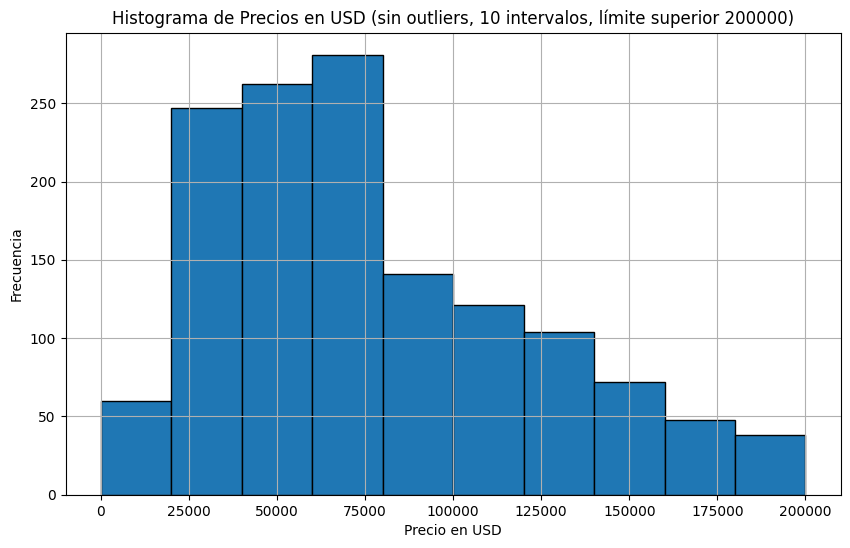

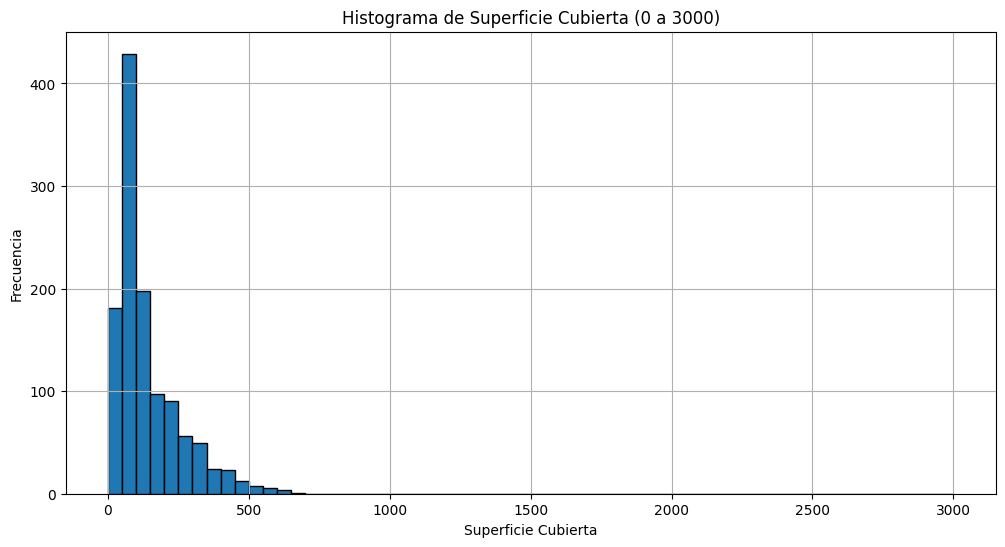

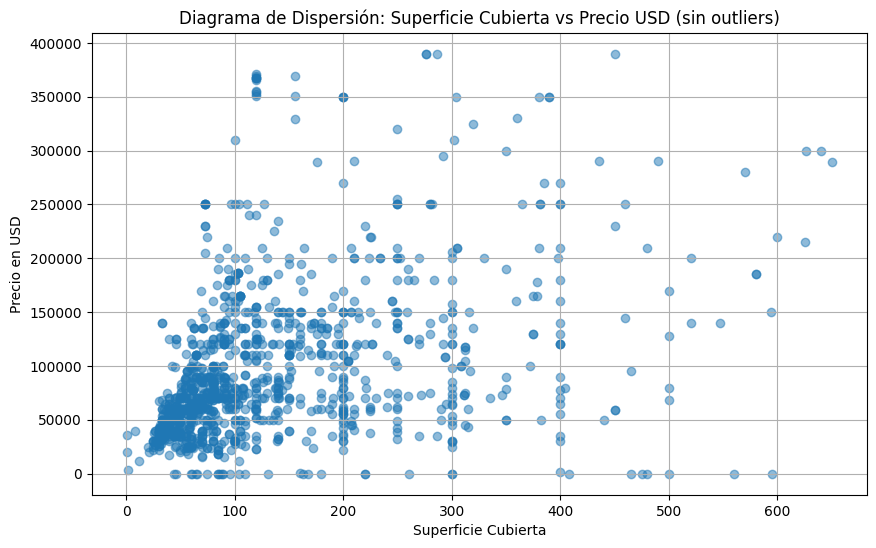

In [41]:
# 1) Identificar variables cuantitativas y cualitativas
quantitative_vars = inmob_df.select_dtypes(include=np.number).columns.tolist()
qualitative_vars = inmob_df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Variables Cuantitativas:")
print(quantitative_vars)

print("\nVariables Cualitativas:")
qualitative_vars

# 2) Crea el histograma con 10 intervalos en Precio_USD con 200000 como limite inferior del mayor intervalo

# elimina filas con valores fuera del intervalo +/- 3 desvios estandar en el campo Precio_USD y luego realiza un histograma con 10 intervalos iguales en esa variable
# Calcula la media y la desviación estándar de 'Precio_USD'
mean_price = inmob_df['Precio_USD'].mean()
std_price = inmob_df['Precio_USD'].std()

# Define los límites para eliminar outliers - 3 Std dev
lower_bound = mean_price - 3 * std_price
upper_bound = mean_price + 3 * std_price

# Filtra el DataFrame para eliminar outliers
inmob_df = inmob_df[(inmob_df['Precio_USD'] >= lower_bound) & (inmob_df['Precio_USD'] <= upper_bound)]
# Encuentra el máximo valor de 'Precio_USD' que no sea outlier.
max_price = inmob_df['Precio_USD'].max()

# Crea el histograma con 10 intervalos y límite superior definido.
plt.figure(figsize=(10, 6))
plt.hist(inmob_df['Precio_USD'], bins=10, range=(inmob_df['Precio_USD'].min(), 200000), edgecolor='black')
plt.xlabel('Precio en USD')
plt.ylabel('Frecuencia')
plt.title('Histograma de Precios en USD (sin outliers, 10 intervalos, límite superior 200000)')
plt.grid(True)
plt.show()

# 3) Diagrama de dispersion entre Sup. CUbierta y Precio USD
# Mostrar histograma de 'Sup. cubierta' entre 0 y 3000 con intervalos de 50
plt.figure(figsize=(12, 6))
plt.hist(inmob_df['Sup. cubierta'].dropna(), bins=np.arange(0, 3050, 50), edgecolor='black')
plt.xlabel('Superficie Cubierta')
plt.ylabel('Frecuencia')
plt.title('Histograma de Superficie Cubierta (0 a 3000)')
plt.grid(True)
plt.show()

# Eliminar casos con Sup cubierta > 700
inmob_df = inmob_df[inmob_df['Sup. cubierta'].fillna(0) <= 700]

# Eliminar filas con valores faltantes en 'Sup. cubierta' o 'Precio_USD'
df_cleaned = inmob_df.dropna(subset=['Sup. cubierta', 'Precio_USD'])

# Crear el diagrama de dispersión
plt.figure(figsize=(10, 6))
plt.scatter(df_cleaned['Sup. cubierta'], df_cleaned['Precio_USD'], alpha=0.5)
plt.xlabel('Superficie Cubierta')
plt.ylabel('Precio en USD')
plt.title('Diagrama de Dispersión: Superficie Cubierta vs Precio USD (sin outliers)')
plt.grid(True)
plt.show()


In [45]:
# prompt: Calcula estadisticas descriptivas (incluyendo mediana y moda) para todas estas variables:  'Expensas', 'Latitud', 'Longitud', 'Ambientes', 'Sup. cubierta', 'Dormitorios', 'Antiguedad', 'Baños', 'Estado', 'Disposición', 'Cocheras', 'Precio_USD'. Presenta los float con hasta 2 digitos

import pandas as pd
def describe_numeric_vars(df, variables):
  """
  Calcula y presenta estadísticas descriptivas para variables numéricas,
  incluyendo mediana y moda, con formato a 2 decimales.

  Args:
    df (pd.DataFrame): El DataFrame de pandas.
    variables (list): Una lista de nombres de columnas numéricas.
  """
  for var in variables:
    if var in df.columns and pd.api.types.is_numeric_dtype(df[var]):
      print(f"\nEstadísticas descriptivas para '{var}':")
      # Calcula las estadísticas descriptivas básicas
      desc = df[var].describe().apply(lambda x: f'{x:.2f}' if isinstance(x, (int, float)) else x)
      print(desc)

      # Calcula la mediana
      mediana = df[var].median()
      print(f"Mediana: {mediana:.2f}")

      # Calcula la moda
      # value_counts(dropna=False) para incluir NaN si existen
      moda_series = df[var].mode()
      if not moda_series.empty:
          # Si hay una moda (o varias), tomamos la primera para simplificar la presentación
          moda = moda_series[0]
          if isinstance(moda, (int, float)):
              print(f"Moda: {moda:.2f}")
          else:
               print(f"Moda: {moda}") # Para casos no numéricos como NaN si mode() devuelve NaN
      else:
          print("Moda: No hay moda única (o todos los valores son únicos)")

      print("-" * 30)
    elif var in df.columns:
        print(f"\nLa variable '{var}' no es numérica y no se calcularán estadísticas descriptivas estándar.")
    else:
        print(f"\nLa variable '{var}' no se encuentra en el DataFrame.")

# Variables para las que queremos estadísticas descriptivas
vars_to_describe = ['Expensas', 'Latitud', 'Longitud', 'Ambientes', 'Sup. cubierta',
                    'Dormitorios', 'Antiguedad', 'Baños', 'Estado', 'Disposición',
                    'Cocheras', 'Precio_USD']

# Llamar a la función con el DataFrame y la lista de variables
describe_numeric_vars(inmob_df, vars_to_describe)


Estadísticas descriptivas para 'Expensas':
count        266.00
mean       74379.39
std       128477.29
min            1.00
25%        20000.00
50%        50000.00
75%       110000.00
max      1900000.00
Name: Expensas, dtype: object
Mediana: 50000.00
Moda: 20000.00
------------------------------

Estadísticas descriptivas para 'Latitud':
count    1419.00
mean      -27.58
std         1.62
min       -53.77
25%       -27.46
50%       -27.45
75%       -27.44
max       -26.59
Name: Latitud, dtype: object
Mediana: -27.45
Moda: -27.60
------------------------------

Estadísticas descriptivas para 'Longitud':
count    1419.00
mean      -59.03
std         0.54
min       -67.71
25%       -59.00
50%       -58.99
75%       -58.98
max       -58.38
Name: Longitud, dtype: object
Mediana: -58.99
Moda: -59.19
------------------------------

Estadísticas descriptivas para 'Ambientes':
count    985.00
mean       3.53
std        1.82
min        1.00
25%        2.00
50%        3.00
75%        4.00
max    

/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_axes.py:7065: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_axes.py:7066: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

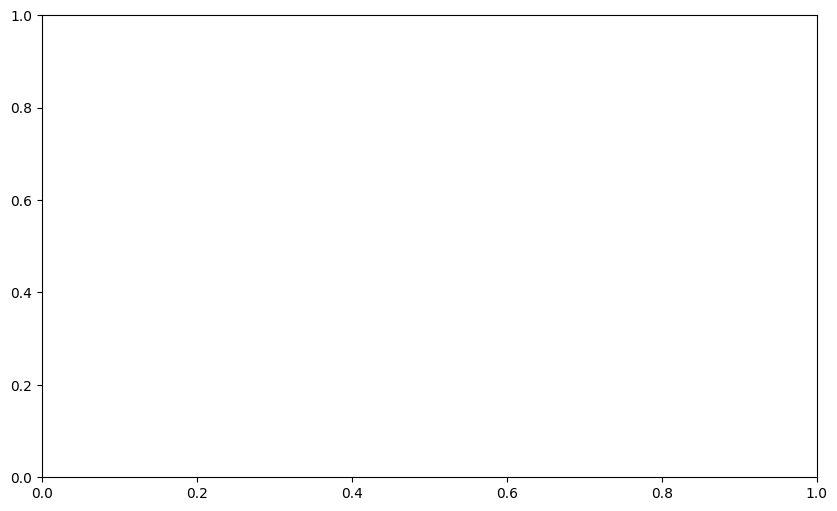

In [ ]:
# prompt: Para las filas en que Moneda es vacio, realiza un histograma de la variable Precio con 10 intervalos

# Filtrar las filas donde 'Moneda' está vacía
empty_moneda_df = inmob_df[inmob_df['Moneda'] == '']

# Crear el histograma para la columna 'Precio' con 10 intervalos
plt.figure(figsize=(10, 6))
plt.hist(empty_moneda_df['Precio'], bins=10, edgecolor='black')
plt.title('Histograma de Precio para Moneda vacía')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


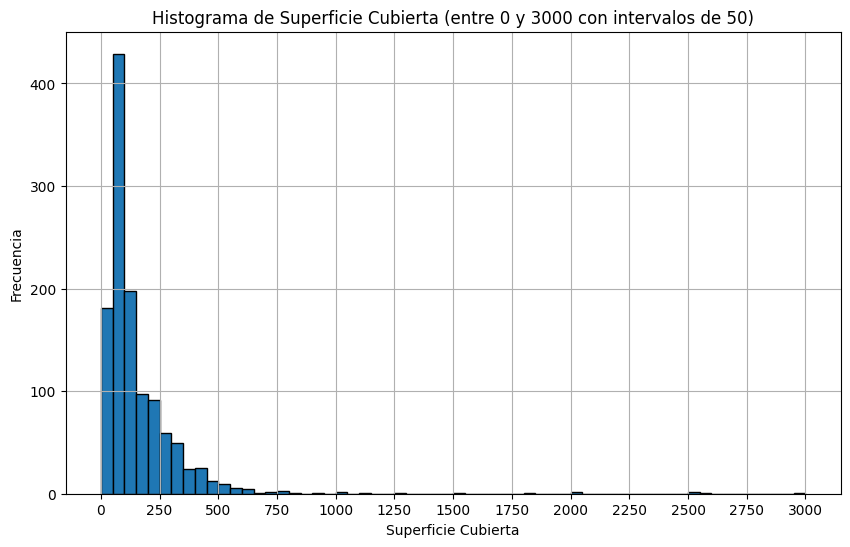

<Axes: >

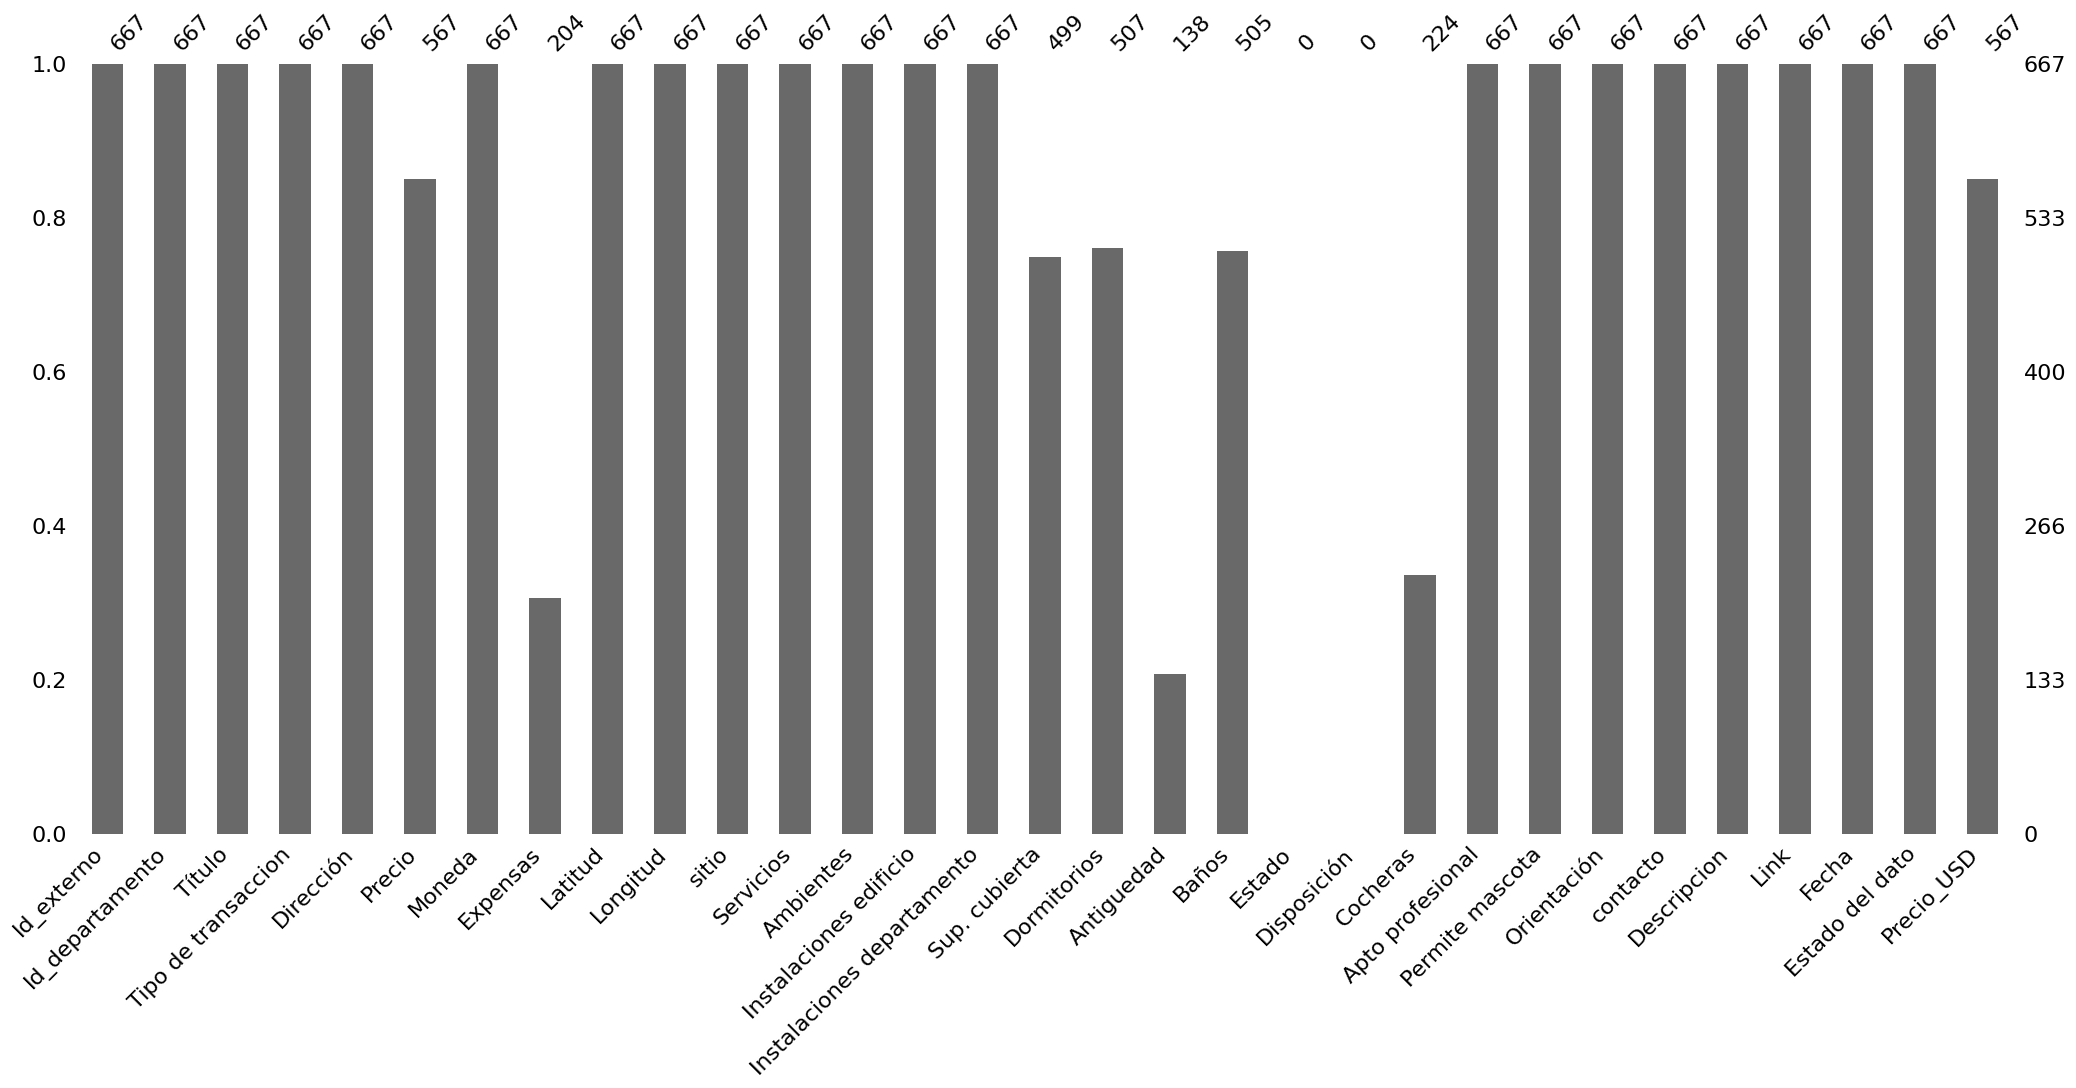

In [ ]:
msno.bar(inmob_df) # Cantidad de valores faltantes por columna